In [4]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

In [5]:
#preparing test dataset
from sklearn.datasets import make_circles
n_samples=1000
X,y=make_circles(n_samples, noise=0.03, random_state=7)
print(X[:5])
print(y[:5])

[[-0.75681927 -0.27401115]
 [-0.48167671 -0.87409407]
 [-0.97024009 -0.25205207]
 [-0.66094436 -0.49907384]
 [-0.90793058  0.40841756]]
[1 0 0 1 0]


In [6]:
X.shape , y.shape

((1000, 2), (1000,))

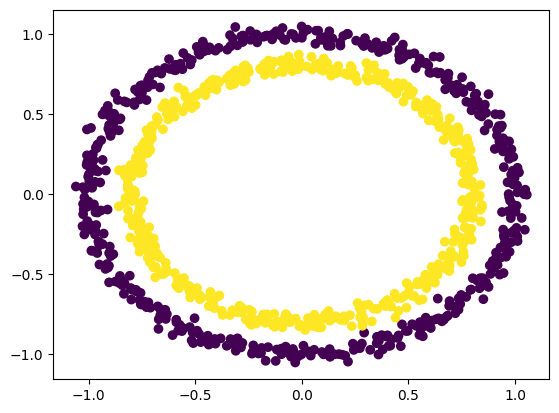

In [7]:
plt.scatter(x=X[:,0],y=X[:,1],c=y);

In [8]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
X

tensor([[-0.7568, -0.2740],
        [-0.4817, -0.8741],
        [-0.9702, -0.2521],
        ...,
        [ 0.7447,  0.3348],
        [-0.7825,  0.6540],
        [-0.6232,  0.8435]])

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=7)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [10]:
from torch import nn
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
class Circlemodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1=nn.Linear(in_features=2, out_features=5)
        self.linear_2=nn.Linear(in_features=5, out_features=1)
    def forward(self, X):
        return self.linear_2(self.linear_1)

model_0= Circlemodel()
model_0   

Circlemodel(
  (linear_1): Linear(in_features=2, out_features=5, bias=True)
  (linear_2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:
model_0=nn.Sequential(nn.Linear(in_features=2,out_features=5),
                      nn.Linear(in_features=5, out_features=1)).to(device)
model_0


Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [14]:
def accuracy(y_true, y_predic):
    correct=torch.eq(y_true,y_predic).sum().item()
    acc=(correct/len(y_predic))*100
    return acc

In [15]:
y_logits=model_0(X_test.to(device))
y_logits[:5]

tensor([[0.1022],
        [0.2277],
        [0.4347],
        [0.3934],
        [0.0011]], device='cuda:0', grad_fn=<SliceBackward0>)

In [16]:
y_pred_logits=torch.sigmoid(y_logits)
y_pred_logits[:5]

tensor([[0.5255],
        [0.5567],
        [0.6070],
        [0.5971],
        [0.5003]], device='cuda:0', grad_fn=<SliceBackward0>)

In [17]:
torch.round(y_pred_logits)[:5].squeeze()

tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [18]:
#training
torch.manual_seed(7)
epochs=100

X_train, X_test = X_train.to(device) , X_test.to(device)
y_train, y_test = y_train.to(device) , y_test.to(device)
 
for epoch in range(epochs):
    model_0.train()
    y_logits=model_0(X_train).squeeze()
    y_preds=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits,y_train)
    acc=accuracy(y_true=y_train, y_predic=y_preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits=model_0(X_test).squeeze()
        test_preds=torch.round(torch.sigmoid(test_logits))
        test_loss=loss_fn(test_logits, y_test)
        test_acc=accuracy(y_true=y_test, y_predic=test_preds)
        if epoch%10==0:
            print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")
        


Epoch: 0 | Train loss: 0.7065280079841614 | Test loss: 0.6872602105140686
Epoch: 10 | Train loss: 0.6991975903511047 | Test loss: 0.6908538937568665
Epoch: 20 | Train loss: 0.6966777443885803 | Test loss: 0.6936890482902527
Epoch: 30 | Train loss: 0.695482075214386 | Test loss: 0.6952776312828064
Epoch: 40 | Train loss: 0.6947460770606995 | Test loss: 0.6960850954055786
Epoch: 50 | Train loss: 0.69422847032547 | Test loss: 0.6964904069900513
Epoch: 60 | Train loss: 0.693844735622406 | Test loss: 0.6967068314552307
Epoch: 70 | Train loss: 0.6935545802116394 | Test loss: 0.6968403458595276
Epoch: 80 | Train loss: 0.6933334469795227 | Test loss: 0.696940004825592
Epoch: 90 | Train loss: 0.693164050579071 | Test loss: 0.697026789188385


In [19]:
class CirclemodelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1=nn.Linear(in_features=2, out_features=10)
        self.linear_2=nn.Linear(in_features=10, out_features=10)
        self.linear_3=nn.Linear(in_features=10, out_features=1)
        self.relu=nn.ReLU()
    def forward(self, X):
        return self.linear_3(self.relu(self.linear_2(self.relu(self.linear_1(X)))))    

In [20]:
model_v2=CirclemodelV2().to(device)
model_v2

CirclemodelV2(
  (linear_1): Linear(in_features=2, out_features=10, bias=True)
  (linear_2): Linear(in_features=10, out_features=10, bias=True)
  (linear_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [21]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_v2.parameters(), lr=0.1)

In [22]:
#training
epochs=100
torch.manual_seed(7)
train_loss_vals=[]
test_loss_vals=[]

for epoch in range(epochs):
    model_v2.train()
    y_logits=model_v2(X_train).squeeze()
    y_preds=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits, y_train)
    acc=accuracy(y_true=y_train, y_predic=y_preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_v2.eval()
    with torch.inference_mode():
        test_logits=model_v2(X_test).squeeze()
        test_preds=torch.round(torch.sigmoid(test_logits))
        test_loss=loss_fn(test_logits, y_test)
        test_acc=accuracy(y_true=y_test, y_predic=test_preds)

        if epoch%10==0:
            train_loss_vals.append(loss)
            test_loss_vals.append(test_loss)
            print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")


Epoch: 0 | Train loss: 0.6986761093139648 | Test loss: 0.7167661190032959
Epoch: 10 | Train loss: 0.6959591507911682 | Test loss: 0.7094106674194336
Epoch: 20 | Train loss: 0.694625198841095 | Test loss: 0.7049917578697205
Epoch: 30 | Train loss: 0.6939004063606262 | Test loss: 0.702238917350769
Epoch: 40 | Train loss: 0.693448007106781 | Test loss: 0.700444757938385
Epoch: 50 | Train loss: 0.6931627988815308 | Test loss: 0.6992940902709961
Epoch: 60 | Train loss: 0.6929411292076111 | Test loss: 0.6985073089599609
Epoch: 70 | Train loss: 0.6927514672279358 | Test loss: 0.6979653835296631
Epoch: 80 | Train loss: 0.692578136920929 | Test loss: 0.6975739598274231
Epoch: 90 | Train loss: 0.6924166679382324 | Test loss: 0.6972840428352356


In [23]:
#multi-class data building
from sklearn.datasets import make_blobs
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=77

X_blob, y_blob = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

tensor([[ 4.1750, -5.0190],
        [ 4.9378, -6.6449],
        [-8.4648,  8.0414],
        [ 6.0764, -5.1013],
        [-9.4035,  5.9849]]) tensor([1, 1, 2, 1, 2])


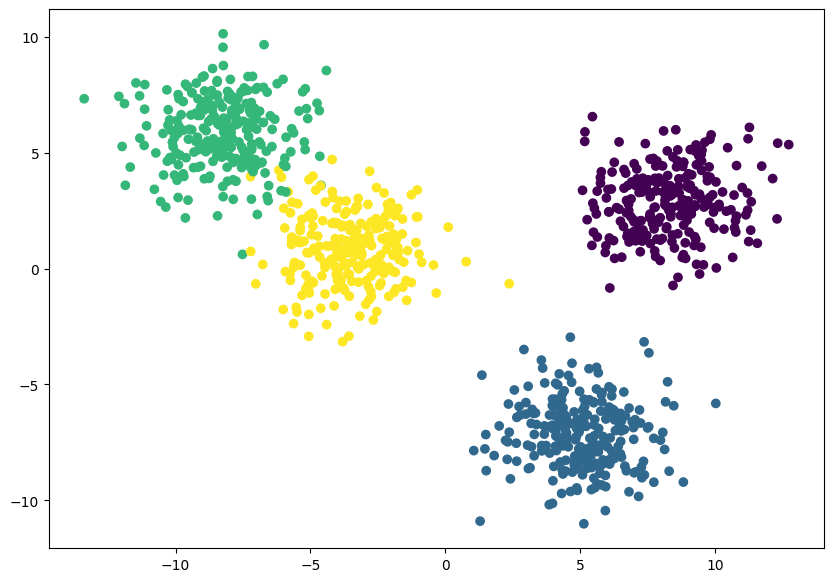

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_blob,y_blob, test_size=0.2, random_state=7)
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1], c=y_blob);

In [25]:
class mutlimodel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack=nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward(self,X):
        return self.linear_layer_stack(X)
    
model_v3=mutlimodel(2, 4).to(device)
model_v3

mutlimodel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [26]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test=y_train.to(device), y_test.to(device)
logits=model_v3(X_train)
logits[:5]

tensor([[ 0.5006, -1.2298, -0.5425,  0.1365],
        [ 0.2930, -0.6891, -0.1551, -0.1028],
        [-0.0693,  1.1144, -0.4504,  0.5735],
        [ 0.5948, -1.4282, -0.7714,  0.3049],
        [ 0.0201,  0.8989, -0.6368,  0.6986]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [27]:
logits_pred = torch.softmax(logits, dim=1)
logits_pred[:5]

tensor([[0.4496, 0.0797, 0.1584, 0.3124],
        [0.3722, 0.1394, 0.2378, 0.2506],
        [0.1460, 0.4768, 0.0997, 0.2776],
        [0.4683, 0.0619, 0.1194, 0.3504],
        [0.1696, 0.4083, 0.0879, 0.3342]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [28]:
torch.argmax(logits_pred,dim=1)[:5]

tensor([0, 0, 1, 0, 1], device='cuda:0')

In [29]:
torch.argmax(torch.softmax(logits,dim=1),dim=1)[:5]

tensor([0, 0, 1, 0, 1], device='cuda:0')

In [30]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_v3.parameters(), lr=0.1)

In [34]:
#training
epochs=100
epoch_count=[]

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

train_loss_vals=[]
test_loss_vals=[]
torch.manual_seed(77)

for epoch in range(epochs):
    model_v3.train()
    y_logits=model_v3(X_train)
    y_preds=torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    loss=loss_fn(y_logits, y_train)
    acc=accuracy(y_true=y_train, y_predic=y_preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_v3.eval()
    with torch.inference_mode():
        test_logits=model_v3(X_test)
        test_preds=torch.argmax(torch.softmax(test_logits, dim=1), dim=1)
        test_loss=loss_fn(test_logits, y_test)
        test_acc=accuracy(y_true=y_test, y_predic=test_preds)

        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_vals.append(loss)
            test_loss_vals.append(test_loss)
            print(f"Epoch: {epoch} | Train loss: {loss} | Train acc: {acc} | Test loss: {test_loss} | Test acc: {test_acc}")

    

Epoch: 0 | Train loss: 0.05290617048740387 | Train acc: 98.625 | Test loss: 0.04436603561043739 | Test acc: 99.0
Epoch: 10 | Train loss: 0.05037517845630646 | Train acc: 98.875 | Test loss: 0.04227790981531143 | Test acc: 99.0
Epoch: 20 | Train loss: 0.04811796545982361 | Train acc: 98.875 | Test loss: 0.040409382432699203 | Test acc: 99.0
Epoch: 30 | Train loss: 0.04610108956694603 | Train acc: 98.875 | Test loss: 0.03873312100768089 | Test acc: 99.0
Epoch: 40 | Train loss: 0.04429487884044647 | Train acc: 99.0 | Test loss: 0.03722500428557396 | Test acc: 99.0
Epoch: 50 | Train loss: 0.042673259973526 | Train acc: 99.0 | Test loss: 0.03586390241980553 | Test acc: 99.0
Epoch: 60 | Train loss: 0.04121346399188042 | Train acc: 99.0 | Test loss: 0.034631580114364624 | Test acc: 99.0
Epoch: 70 | Train loss: 0.03989574685692787 | Train acc: 99.0 | Test loss: 0.03351224958896637 | Test acc: 99.0
Epoch: 80 | Train loss: 0.03870294615626335 | Train acc: 99.0 | Test loss: 0.03249230980873108 | 

In [35]:
from torchmetrics import Accuracy
accrcy=Accuracy(task='multiclass', num_classes=4).to(device)
accrcy

MulticlassAccuracy()

In [43]:
logits=model_v3(X_test)
preds=torch.argmax(torch.softmax(logits, dim=1), dim=1)
preds[:10]

tensor([3, 2, 0, 3, 0, 2, 1, 0, 3, 3], device='cuda:0')

In [44]:
accrcy(preds, y_test)

tensor(0.9900, device='cuda:0')

In [46]:
model_v3.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.1587, -0.5813],
                      [ 0.0692,  0.3813],
                      [-0.6460,  0.1692],
                      [-0.7365,  0.1859],
                      [-0.2695,  0.5718],
                      [ 0.7361, -0.0500],
                      [-0.4955, -0.5436],
                      [ 0.0071, -0.2569]], device='cuda:0')),
             ('linear_layer_stack.0.bias',
              tensor([ 0.2551, -0.6458,  0.9528, -1.0487,  0.4331, -0.1142,  0.7071,  0.4552],
                     device='cuda:0')),
             ('linear_layer_stack.1.weight',
              tensor([[-7.9983e-02, -1.6636e-03,  5.7238e-01,  3.0436e-01,  3.6382e-01,
                       -5.6901e-01,  4.3884e-01,  1.4561e-01],
                      [-1.6350e-01,  3.5603e-01, -6.2352e-02,  7.5292e-01, -9.8195e-02,
                       -2.2720e-01, -3.5151e-01, -4.0885e-01],
                      [ 1.9193e-01, -1.4444e-01, -2.3943e-01,  4.2211e-01,

In [53]:
from pathlib import Path
PATH=Path("models")
MODEL_NAME="model_v3"
MODEL_PATH=PATH/MODEL_NAME

torch.save(obj=model_v3.state_dict(), f=MODEL_PATH)